# Telco Customer Churn — Classification Project

**Author:** Zakee Ul Hassan
**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers

**Goal:** Predict which customers will churn, identify the strongest churn drivers, and provide a business recommendation.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print("Data loaded successfully!")
print("Shape:",df.shape)

df.tail(10)

Data loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [9]:
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nChurn rate (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Initial Observations

- **7,043 customers, 21 columns**, one ID (`customerID`), 19 features, and the target (`Churn`).
- **Class imbalance:** ~73% No, ~27% Yes (1,869 churners). This is significant accuracy alone will be misleading. Will need to track recall, precision, F1, and ROC-AUC.
- **`TotalCharges` is stored as `object`** (text), not numeric. Likely contains some empty strings or whitespace where total charges should be. Will need to clean and convert during preprocessing.
- **Mixed encoding for binary fields:** `SeniorCitizen` is already 0/1, but `Partner`, `Dependents`, `PaperlessBilling`, `Churn` are "Yes"/"No" strings. Will normalize during preprocessing.
- **Service columns have three values, not two** — many include "No internet service" in addition to Yes/No. Need to decide whether to treat as a third category or collapse to binary.
- **Tenure ranges 0 to 72 months** — note that 0-tenure customers may be brand-new and behave differently from established customers; worth checking churn rate by tenure later.

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
print("Data type of TotalCharges:", df["TotalCharges"].dtype)
print("Number of null values in TotalCharges:", df["TotalCharges"].isnull().sum())

Data type of TotalCharges: float64
Number of null values in TotalCharges: 11


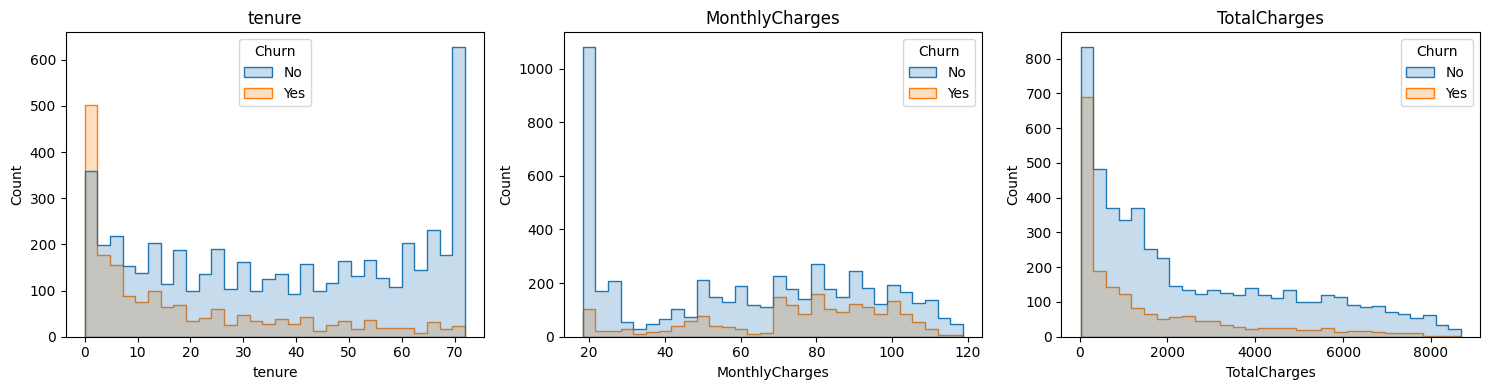

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, ax=axes[i], element='step')
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

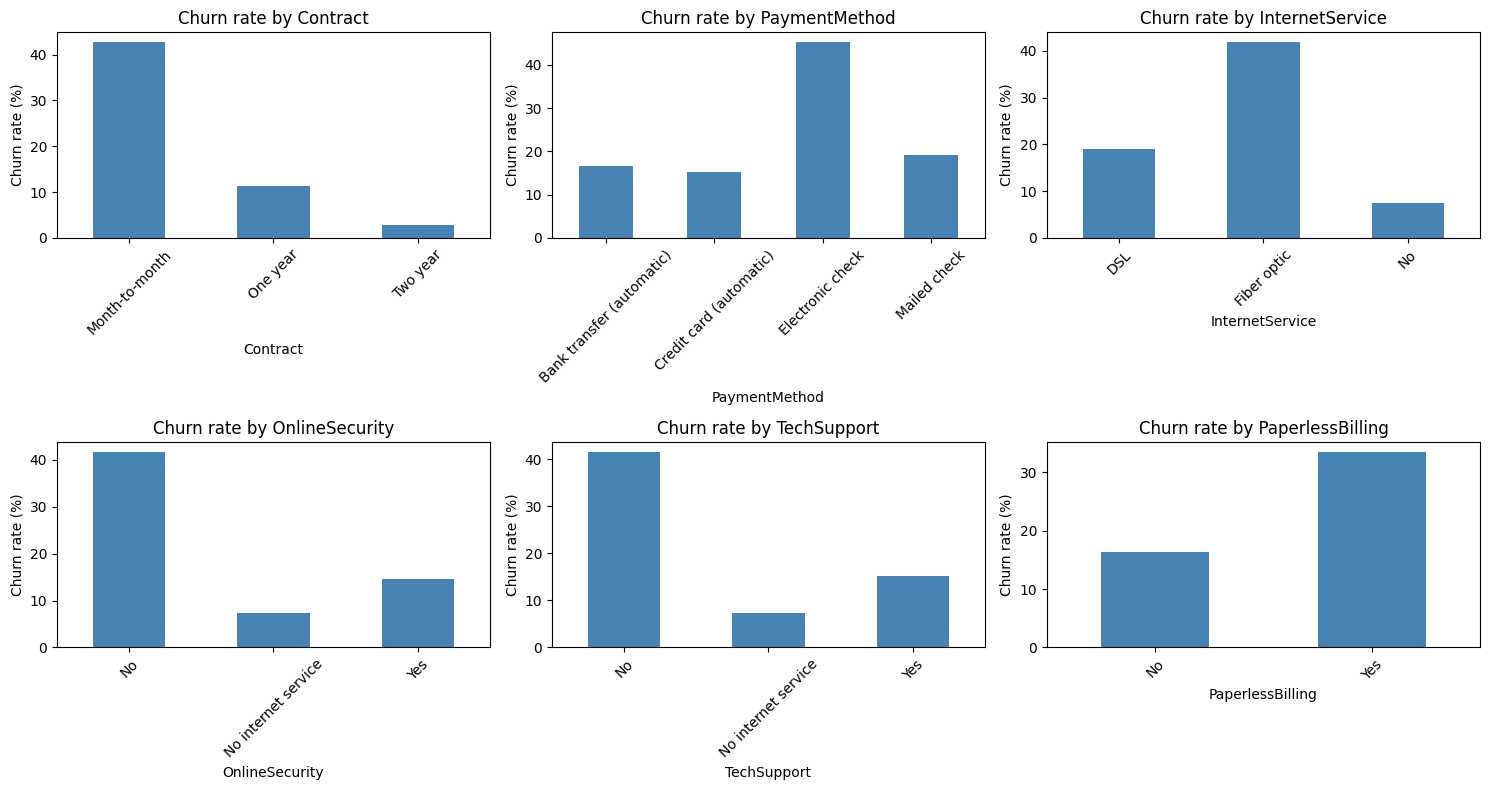

In [29]:
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()


for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../churn_rates.png', dpi=100, bbox_inches='tight')
plt.show()

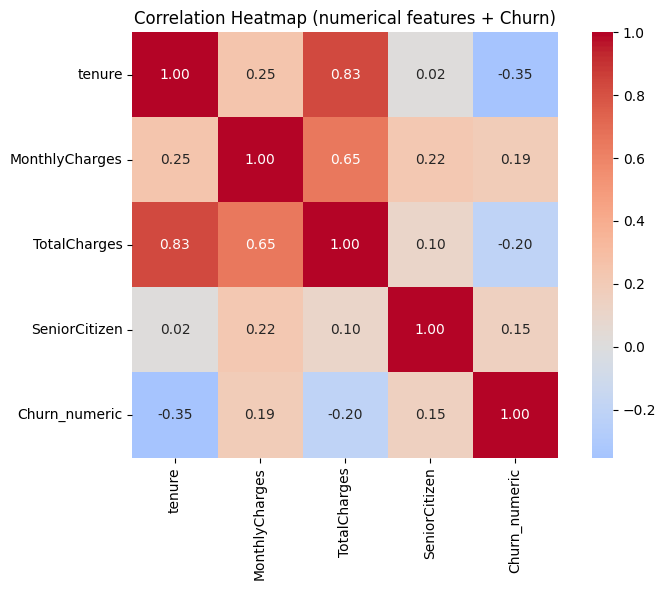

In [30]:
df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                'SeniorCitizen', 'Churn_numeric']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation Heatmap (numerical features + Churn)')
plt.tight_layout()
plt.savefig('../correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### EDA Findings Summary

**Strongest churn signals:**
- **Contract type** (categorical): month-to-month customers churn ~42%, two-year customers <3% — by far the biggest predictor.
- **tenure** (numeric): correlation of -0.35 with churn. Newer customers are much more likely to leave.
- **MonthlyCharges** (numeric): correlation of +0.19. Higher-paying customers churn slightly more.

**Categorical predictors with strong effects:**
- PaymentMethod (electronic check users churn ~45%)
- InternetService (fiber optic users churn more than DSL — counterintuitive)
- OnlineSecurity, TechSupport (customers without these add-ons churn 3-4× more)

**Weaker predictors, but kept for modeling:** PaperlessBilling, demographics. Whether they earn their keep will be decided by feature importance, not EDA.

**Multicollinearity warning:**
- `tenure` and `TotalCharges` are highly correlated (+0.83) since TotalCharges ≈ tenure × MonthlyCharges. May affect interpretability but tree-based models handle this fine.

**Data quality note:**
- 11 missing values in `TotalCharges` after numeric conversion — all corresponding to tenure=0 (brand-new customers). Will impute or drop during preprocessing.